# XGBoost & LightGBM Regression Models

This notebook trains and evaluates both XGBoost and LightGBM models, comparing their performance.

## 1. Setup & Imports

In [1]:
import sys
sys.path.append('..')

from src.data_loader import load_processed_data
from src.evaluation import perform_kfold_cv, calculate_metrics, save_results_json, create_results_dict
import time
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb

## 2. Load Preprocessed Data

In [2]:
print("Loading preprocessed data...")
X_train, X_test, y_train, y_test = load_processed_data()
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Loading preprocessed data...
✓ Loaded processed data from data/processed/
  Train: (6766, 5), Test: (1692, 5)
Train set: (6766, 5), Test set: (1692, 5)


## 3. Train XGBoost Model

In [3]:
print("=" * 60)
print("TRAINING XGBOOST")
print("=" * 60)

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print(f"Model: {xgb_model}")

# Train
print("\nTraining XGBoost...")
start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_training_time = time.time() - start_time
print(f"✓ Training completed in {xgb_training_time:.4f}s")

# Cross-validation
print("\nPerforming 10-fold cross-validation...")
xgb_cv_results = perform_kfold_cv(xgb_model, X_train, y_train, k=10)
print(f"\nCV RMSE: {xgb_cv_results['rmse_mean']:.2f} ± {xgb_cv_results['rmse_std']:.2f}")
print(f"CV R²: {xgb_cv_results['r2_mean']:.4f} ± {xgb_cv_results['r2_std']:.4f}")

# Test evaluation
print("\nEvaluating on test set...")
xgb_y_pred = xgb_model.predict(X_test)
xgb_test_rmse, xgb_test_r2 = calculate_metrics(y_test, xgb_y_pred)
print(f"Test RMSE: {xgb_test_rmse:.2f}")
print(f"Test R²: {xgb_test_r2:.4f}")

TRAINING XGBOOST
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Training XGBoost...


✓ Training completed in 0.2545s

Performing 10-fold cross-validation...
Performing 10-fold cross-validation...
  Fold 1/10: RMSE=1052.87, R²=0.9219
  Fold 2/10: RMSE=695.23, R²=0.9666
  Fold 3/10: RMSE=1074.56, R²=0.9072
  Fold 4/10: RMSE=799.28, R²=0.9329
  Fold 5/10: RMSE=1026.89, R²=0.9438
  Fold 6/10: RMSE=523.00, R²=0.8224
  Fold 7/10: RMSE=843.85, R²=0.8918
  Fold 8/10: RMSE=751.84, R²=0.9236
  Fold 9/10: RMSE=839.83, R²=0.9294


  Fold 10/10: RMSE=750.65, R²=0.9069

  CV Results:
    RMSE: 835.80 ± 165.52
    R²:   0.9146 ± 0.0366

CV RMSE: 835.80 ± 165.52
CV R²: 0.9146 ± 0.0366

Evaluating on test set...
Test RMSE: 643.85
Test R²: 0.9303


## 4. Train LightGBM Model

In [4]:
print("\n" + "=" * 60)
print("TRAINING LIGHTGBM")
print("=" * 60)

lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbose=-1
)

print(f"Model: {lgb_model}")

# Train
print("\nTraining LightGBM...")
start_time = time.time()
lgb_model.fit(X_train, y_train)
lgb_training_time = time.time() - start_time
print(f"✓ Training completed in {lgb_training_time:.4f}s")

# Cross-validation
print("\nPerforming 10-fold cross-validation...")
lgb_cv_results = perform_kfold_cv(lgb_model, X_train, y_train, k=10)
print(f"\nCV RMSE: {lgb_cv_results['rmse_mean']:.2f} ± {lgb_cv_results['rmse_std']:.2f}")
print(f"CV R²: {lgb_cv_results['r2_mean']:.4f} ± {lgb_cv_results['r2_std']:.4f}")

# Test evaluation
print("\nEvaluating on test set...")
lgb_y_pred = lgb_model.predict(X_test)
lgb_test_rmse, lgb_test_r2 = calculate_metrics(y_test, lgb_y_pred)
print(f"Test RMSE: {lgb_test_rmse:.2f}")
print(f"Test R²: {lgb_test_r2:.4f}")


TRAINING LIGHTGBM
Model: LGBMRegressor(max_depth=3, random_state=42, verbose=-1)

Training LightGBM...
✓ Training completed in 0.0316s

Performing 10-fold cross-validation...
Performing 10-fold cross-validation...
  Fold 1/10: RMSE=1091.04, R²=0.9162
  Fold 2/10: RMSE=779.94, R²=0.9579
  Fold 3/10: RMSE=1166.70, R²=0.8906
  Fold 4/10: RMSE=878.26, R²=0.9189


  Fold 5/10: RMSE=1143.76, R²=0.9302
  Fold 6/10: RMSE=537.57, R²=0.8124
  Fold 7/10: RMSE=897.81, R²=0.8775
  Fold 8/10: RMSE=839.23, R²=0.9049


  Fold 9/10: RMSE=925.29, R²=0.9143
  Fold 10/10: RMSE=873.36, R²=0.8740

  CV Results:
    RMSE: 913.30 ± 177.92
    R²:   0.8997 ± 0.0375

CV RMSE: 913.30 ± 177.92
CV R²: 0.8997 ± 0.0375

Evaluating on test set...
Test RMSE: 715.73
Test R²: 0.9139


## 5. Compare Models

In [5]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'CV_RMSE_Mean': [xgb_cv_results['rmse_mean'], lgb_cv_results['rmse_mean']],
    'CV_RMSE_Std': [xgb_cv_results['rmse_std'], lgb_cv_results['rmse_std']],
    'CV_R2_Mean': [xgb_cv_results['r2_mean'], lgb_cv_results['r2_mean']],
    'CV_R2_Std': [xgb_cv_results['r2_std'], lgb_cv_results['r2_std']],
    'Test_RMSE': [xgb_test_rmse, lgb_test_rmse],
    'Test_R2': [xgb_test_r2, lgb_test_r2],
    'Training_Time': [xgb_training_time, lgb_training_time]
})

print(comparison.to_string(index=False))

# Determine better model
if xgb_cv_results['rmse_mean'] < lgb_cv_results['rmse_mean']:
    best_model_name = "XGBoost"
    best_model = xgb_model
    best_cv_results = xgb_cv_results
    best_test_rmse = xgb_test_rmse
    best_test_r2 = xgb_test_r2
    best_training_time = xgb_training_time
    best_y_pred = xgb_y_pred
else:
    best_model_name = "LightGBM"
    best_model = lgb_model
    best_cv_results = lgb_cv_results
    best_test_rmse = lgb_test_rmse
    best_test_r2 = lgb_test_r2
    best_training_time = lgb_training_time
    best_y_pred = lgb_y_pred

print(f"\n✓ Best model: {best_model_name}")


MODEL COMPARISON
   Model  CV_RMSE_Mean  CV_RMSE_Std  CV_R2_Mean  CV_R2_Std  Test_RMSE  Test_R2  Training_Time
 XGBoost    835.801089   165.516773    0.914646   0.036572 643.854013 0.930340       0.254503
LightGBM    913.295795   177.920689    0.899689   0.037509 715.732974 0.913919       0.031637

✓ Best model: XGBoost


## 6. Save Results (Best Model)

In [6]:
# Save both models' results in one file
results = {
    "comparison": "XGBoost vs LightGBM",
    "best_model": best_model_name,
    "xgboost": create_results_dict(
        algorithm="XGBoost",
        model=xgb_model,
        X_train=X_train,
        cv_results=xgb_cv_results,
        test_scores={'rmse': float(xgb_test_rmse), 'r2': float(xgb_test_r2)},
        training_time=xgb_training_time
    ),
    "lightgbm": create_results_dict(
        algorithm="LightGBM",
        model=lgb_model,
        X_train=X_train,
        cv_results=lgb_cv_results,
        test_scores={'rmse': float(lgb_test_rmse), 'r2': float(lgb_test_r2)},
        training_time=lgb_training_time
    )
}

save_results_json(results, "08_xgboost_lightgbm.json")
print("✓ Results saved to ../results/08_xgboost_lightgbm.json")


✓ Results saved to results/08_xgboost_lightgbm.json
✓ Results saved to ../results/08_xgboost_lightgbm.json


## 7. Visualization

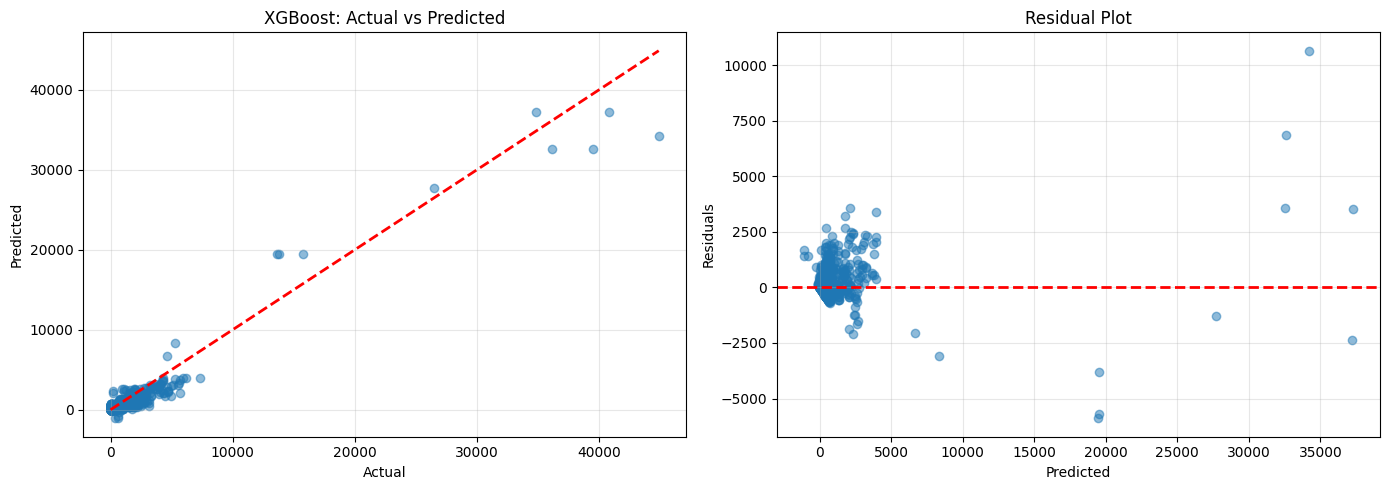

In [7]:
# Actual vs Predicted for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, best_y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_model_name}: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - best_y_pred
axes[1].scatter(best_y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
print("\n" + "="*60)
print("XGBOOST & LIGHTGBM COMPARISON COMPLETE!")
print("="*60)
print(f"\nBest Model: {best_model_name}")
print(f"CV RMSE: {best_cv_results['rmse_mean']:.2f} ± {best_cv_results['rmse_std']:.2f}")
print(f"CV R²: {best_cv_results['r2_mean']:.4f} ± {best_cv_results['r2_std']:.4f}")
print(f"Test RMSE: {best_test_rmse:.2f}")
print(f"Test R²: {best_test_r2:.4f}")
print("="*60)


XGBOOST & LIGHTGBM COMPARISON COMPLETE!

Best Model: XGBoost
CV RMSE: 835.80 ± 165.52
CV R²: 0.9146 ± 0.0366
Test RMSE: 643.85
Test R²: 0.9303
